# LIBERO + V-JEPA2 Planning Notebook

This notebook shows how to:

1. Create a gym-like LIBERO environment that supports `reset`, `step`, and state queries.
2. Load tasks and init states from LIBERO benchmarks.
3. Render/init from `droidview` frames.
4. Pass frames into the V-JEPA2 world model and run MPC (CEM) planning.

It combines patterns from:
- `lerobot-libero/notebooks/quick_walkthrough.ipynb`
- `vjepa2/notebooks/energy_landscape_example.ipynb`

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation

# Notebook lives in vjepa2/notebooks, so add vjepa2 repo root for app/src imports.
sys.path.insert(0, "..")

from app.vjepa_droid.transforms import make_transforms
from utils.world_model_wrapper import WorldModel
from utils.mpc_utils import compute_new_pose

# Try installed `libero` first, then fall back to sibling repo path.
try:
    from libero.libero import benchmark, get_libero_path
    from libero.libero.envs import OffScreenRenderEnv
except ImportError:
    sys.path.insert(0, "../../lerobot-libero")
    from libero.libero import benchmark, get_libero_path
    from libero.libero.envs import OffScreenRenderEnv


device = "cuda:1" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

[robosuite WARNING] No private macro file found! (__init__.py:7)


[WARNING ][2026-03-11 16:30:28][robosuite_logs      ][<module>                 ] No private macro file found!


[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)


[WARNING ][2026-03-11 16:30:28][robosuite_logs      ][<module>                 ] It is recommended to use a private macro file


[robosuite WARNING] To setup, run: python /home/hubertchang/miniconda3/envs/vjepa2_libero/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


[WARNING ][2026-03-11 16:30:28][robosuite_logs      ][<module>                 ] To setup, run: python /home/hubertchang/miniconda3/envs/vjepa2_libero/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py
[INFO    ][2026-03-11 16:30:29][OpenGL.acceleratesupport][<module>                 ] No OpenGL_accelerate module loaded: No module named 'OpenGL_accelerate'
Using device: cuda:1


In [2]:
def resolve_bddl_path(bddl_path_from_meta: str) -> str:
    """Resolve BDDL file path robustly across local setups."""
    if os.path.exists(bddl_path_from_meta):
        return bddl_path_from_meta

    benchmark_root = get_libero_path("benchmark_root")
    candidate = os.path.join(benchmark_root, bddl_path_from_meta)
    if os.path.exists(candidate):
        return candidate

    if "bddl_files/" in bddl_path_from_meta:
        rel_under_bddl = bddl_path_from_meta.split("bddl_files/", 1)[1]
        candidate = os.path.join(get_libero_path("bddl_files"), rel_under_bddl)
        if os.path.exists(candidate):
            return candidate

    bddl_root = Path(get_libero_path("bddl_files"))
    basename = Path(bddl_path_from_meta).name
    matches = list(bddl_root.rglob(basename))
    if matches:
        return str(matches[0])

    raise FileNotFoundError(f"Could not resolve BDDL file: {bddl_path_from_meta}")


class LiberoGymLikeEnv:
    """Small gym-like wrapper for LIBERO OffScreenRenderEnv."""

    def __init__(
        self,
        task,
        task_id,
        benchmark_instance,
        camera_name="droidview",
        fallback_camera="sideview",
        camera_height=256,
        camera_width=256,
    ):
        self.task = task
        self.task_id = task_id
        self.benchmark_instance = benchmark_instance
        self.camera_name = camera_name
        self.fallback_camera = fallback_camera
        self.camera_key = f"{camera_name}_image"

        # Prefer benchmark task path; fallback to resolver when needed.
        task_bddl_file = os.path.join(
            get_libero_path("bddl_files"), task.problem_folder, task.bddl_file
        )
        if os.path.exists(task_bddl_file):
            bddl_file = task_bddl_file
        else:
            bddl_file = resolve_bddl_path(task.bddl_file)

        env_kwargs = {
            "bddl_file_name": bddl_file,
            "camera_heights": camera_height,
            "camera_widths": camera_width,
            "camera_depths": False,
            "use_camera_obs": True,
            "has_renderer": False,
            "has_offscreen_renderer": True,
            "ignore_done": True,
        }

        # Try preferred camera, fallback if missing in this task/model.
        try:
            self.env = OffScreenRenderEnv(
                **env_kwargs,
                camera_names=[self.fallback_camera, self.camera_name],
            )
            self.env.reset()
            print(f"Using preferred camera: {self.camera_name}")
        except ValueError as err:
            if self.camera_name in str(err):
                print(
                    f"Preferred camera '{self.camera_name}' unavailable. "
                    f"Falling back to '{self.fallback_camera}'."
                )
                self.env = OffScreenRenderEnv(
                    **env_kwargs,
                    camera_names=[self.fallback_camera],
                )
                self.env.reset()
                self.camera_key = f"{self.fallback_camera}_image"
            else:
                raise
        scene_xml_path = getattr(self.env.env, "_arena_xml", None)
        print(f"Scene XML path: {scene_xml_path}")
        self.init_states = None
        self.last_obs = None

    def reset(self, init_state_idx=0, seed=0):
        self.env.seed(seed)
        self.env.reset()
        self.init_states = self.benchmark_instance.get_task_init_states(self.task_id)
        self.last_obs = self.env.set_init_state(self.init_states[init_state_idx])
        return self.last_obs

    def reset_with_settle(self, init_state_idx=0, seed=0, settle_steps=0, settle_action=None):
        obs = self.reset(init_state_idx=init_state_idx, seed=seed)
        if settle_steps <= 0:
            return obs
        if settle_action is None:
            settle_action = np.zeros(7, dtype=np.float32)
        for _ in range(int(settle_steps)):
            obs, _, _, _ = self.step(settle_action)
        return obs

    def reset_to_state(self, state):
        self.env.reset()
        self.last_obs = self.env.set_init_state(state)
        return self.last_obs

    def step(self, action):
        action = np.asarray(action, dtype=np.float32).reshape(-1)
        if action.shape[0] != 7:
            raise ValueError(f"Expected action shape (7,), got {action.shape}")
        obs, reward, done, info = self.env.step(action)
        self.last_obs = obs
        return obs, reward, done, info

    def get_image(self, obs=None):
        obs = self.last_obs if obs is None else obs
        if self.camera_key not in obs:
            image_keys = sorted([k for k in obs.keys() if k.endswith("_image")])
            raise KeyError(f"{self.camera_key} not in obs. Available image keys: {image_keys}")
        # [::-1] creates a negative-stride view; make contiguous for torch.tensor(...).
        return np.ascontiguousarray(obs[self.camera_key][::-1])

    def get_pose_7d(self, obs=None):
        """[x, y, z, roll, pitch, yaw, gripper]."""
        obs = self.last_obs if obs is None else obs
        pos = np.asarray(obs["robot0_eef_pos"], dtype=np.float32)
        quat = np.asarray(obs["robot0_eef_quat"], dtype=np.float32)
        euler = Rotation.from_quat(quat).as_euler("xyz", degrees=False).astype(np.float32)

        gripper_qpos = np.asarray(obs.get("robot0_gripper_qpos", [0.0]), dtype=np.float32)
        gripper = np.array([float(np.mean(gripper_qpos))], dtype=np.float32)
        return np.concatenate([pos, euler, gripper], axis=0)

    def get_sim_state(self):
        return self.env.get_sim_state()

    def close(self):
        self.env.close()

In [3]:
# Choose task
benchmark_name = "libero_spatial"  # also: libero_object, libero_goal, libero_10, libero_90
task_id = 0
init_state_idx = 0

# Let furniture/objects settle before defining the true initial state.
settle_steps = 10
settle_action = np.zeros(7, dtype=np.float32)

benchmark_instance = benchmark.get_benchmark_dict()[benchmark_name]()
task = benchmark_instance.get_task(task_id)

print(f"Benchmark: {benchmark_name}")
print(f"Task {task_id}: {task.name}")
print(f"Language: {task.language}")

env = LiberoGymLikeEnv(
    task=task,
    task_id=task_id,
    benchmark_instance=benchmark_instance,
    camera_name="droidview2",
    fallback_camera="sideview",
    camera_height=256,
    camera_width=256,
)
obs0 = env.reset_with_settle(
    init_state_idx=init_state_idx,
    seed=0,
    settle_steps=settle_steps,
    settle_action=settle_action,
)
print("Initial sim state length:", len(env.get_sim_state()))
print("Obs image keys:", [k for k in obs0.keys() if k.endswith("_image")])
print("Settle steps:", settle_steps, "Settle action:", settle_action)

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Benchmark: libero_spatial
Task 0: pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate
Language: pick up the black bowl between the plate and the ramekin and place it on the plate
Using preferred camera: droidview2
Scene XML path: /home/hubertchang/p-progress/lerobot-libero/libero/libero/assets/scenes/libero_tabletop_base_style.xml
Initial sim state length: 92
Obs image keys: ['sideview_image', 'droidview2_image']


frames_np: (2, 256, 256, 3)
poses_np: (2, 7)


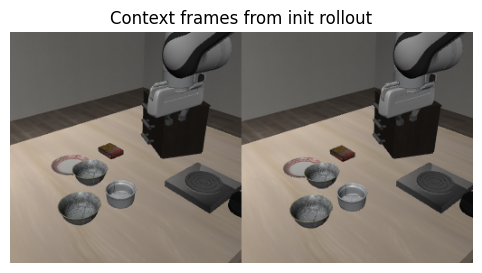

In [4]:
# Load init frames in droidview (same style as quick_walkthrough)
context_len = 2
frames = [env.get_image(obs0)]
poses = [env.get_pose_7d(obs0)]

for _ in range(context_len - 1):
    obs, _, _, _ = env.step(np.zeros(7, dtype=np.float32))
    frames.append(env.get_image(obs))
    poses.append(env.get_pose_7d(obs))

frames_np = np.stack(frames, axis=0)   # [T, H, W, C]
poses_np = np.stack(poses, axis=0)     # [T, 7]

print("frames_np:", frames_np.shape)
print("poses_np:", poses_np.shape)

plt.figure(figsize=(12, 3))
plt.imshow(np.concatenate(frames_np, axis=1))
plt.axis("off")
plt.title("Context frames from init rollout")
plt.show()

In [5]:
# Load V-JEPA2 model and MPC world model wrapper
encoder, predictor = torch.hub.load("facebookresearch/vjepa2", "vjepa2_ac_vit_giant")
encoder = encoder.to(device).eval()
predictor = predictor.to(device).eval()

crop_size = 256
tokens_per_frame = int((crop_size // encoder.patch_size) ** 2)

transform = make_transforms(
    random_horizontal_flip=False,
    random_resize_aspect_ratio=(1.0, 1.0),
    random_resize_scale=(1.0, 1.0),
    reprob=0.0,
    auto_augment=False,
    motion_shift=False,
    crop_size=crop_size,
)

world_model = WorldModel(
    encoder=encoder,
    predictor=predictor,
    tokens_per_frame=tokens_per_frame,
    transform=transform,
    mpc_args={
        "rollout": 1,
        "samples": 800,
        "topk": 10,
        "cem_steps": 10,
        "momentum_mean": 0.15,
        "momentum_mean_gripper": 0.15,
        "momentum_std": 0.75,
        "momentum_std_gripper": 0.15,
        "maxnorm": 0.075,
        "verbose": True,
    },
    normalize_reps=True,
    device=device,
)

Using cache found in /home/hubertchang/.cache/torch/hub/facebookresearch_vjepa2_main
/home/hubertchang/miniconda3/envs/vjepa2_libero/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Probe action: [ 0.   0.  -0.3  0.   0.   0.   0. ] repeat: 50
pose delta [x,y,z,roll,pitch,yaw,gripper]: [ 3.70000e-04  4.68000e-03 -1.95160e-01  6.27246e+00  1.10100e-02
  5.29200e-02 -0.00000e+00]
sim-state L2 delta: 2.618085
frame mean |delta|: 13.194774


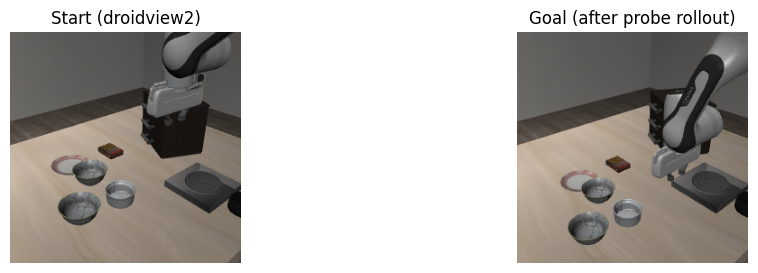

In [6]:
# Build a synthetic goal by rolling out a probe action for multiple env steps.
# Why multi-step? A single small OSC action often produces tiny visual change.
obs_start = env.reset_with_settle(
    init_state_idx=init_state_idx,
    seed=0,
    settle_steps=settle_steps,
    settle_action=settle_action,
)
start_frame = env.get_image(obs_start)
start_pose = env.get_pose_7d(obs_start)
start_sim_state = env.get_sim_state().copy()

probe_action = np.array([0.00, 0.00, -0.30, 0.0, 0.0, 0.0, 0.0], dtype=np.float32)
probe_repeat = 50

obs_goal = None
for _ in range(probe_repeat):
    obs_goal, _, _, _ = env.step(probe_action)

goal_frame = env.get_image(obs_goal)
goal_pose = env.get_pose_7d(obs_goal)
goal_sim_state = env.get_sim_state().copy()

# Diagnostics: confirm that state did change.
pose_delta = goal_pose - start_pose
sim_l2 = float(np.linalg.norm(goal_sim_state - start_sim_state))
pixel_l1 = float(np.mean(np.abs(goal_frame.astype(np.float32) - start_frame.astype(np.float32))))

print("Probe action:", probe_action, "repeat:", probe_repeat)
print("pose delta [x,y,z,roll,pitch,yaw,gripper]:", np.round(pose_delta, 5))
print("sim-state L2 delta:", round(sim_l2, 6))
print("frame mean |delta|:", round(pixel_l1, 6))

# Reset back so planning starts from the same settled init state.
obs_start = env.reset_with_settle(
    init_state_idx=init_state_idx,
    seed=0,
    settle_steps=settle_steps,
    settle_action=settle_action,
)
start_frame = env.get_image(obs_start)
start_pose = env.get_pose_7d(obs_start)

plt.figure(figsize=(12, 3))
plt.subplot(1, 2, 1)
plt.imshow(start_frame)
plt.title("Start (droidview2)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(goal_frame)
plt.title("Goal (after probe rollout)")
plt.axis("off")
plt.show()

/home/hubertchang/miniconda3/envs/vjepa2_libero/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


Starting MPC planning with energy diagnostics...
[INFO    ][2026-03-11 16:32:07][utils.mpc_utils     ][cem                      ] new mean: tensor([-0.0600,  0.0519, -0.0609,  0.6164], device='cuda:1') tensor([0.0583, 0.0592, 0.0579, 0.1903], device='cuda:1')
[INFO    ][2026-03-11 16:32:12][utils.mpc_utils     ][cem                      ] new mean: tensor([-0.0727,  0.0715, -0.0639,  0.7291], device='cuda:1') tensor([0.0437, 0.0444, 0.0459, 0.0312], device='cuda:1')
[INFO    ][2026-03-11 16:32:17][utils.mpc_utils     ][cem                      ] new mean: tensor([-0.0747,  0.0744, -0.0624,  0.7452], device='cuda:1') tensor([0.0328, 0.0333, 0.0353, 0.0076], device='cuda:1')
[INFO    ][2026-03-11 16:32:21][utils.mpc_utils     ][cem                      ] new mean: tensor([-0.0749,  0.0749, -0.0618,  0.7478], device='cuda:1') tensor([0.0246, 0.0250, 0.0273, 0.0029], device='cuda:1')
[INFO    ][2026-03-11 16:32:26][utils.mpc_utils     ][cem                      ] new mean: tensor([-0.0750,

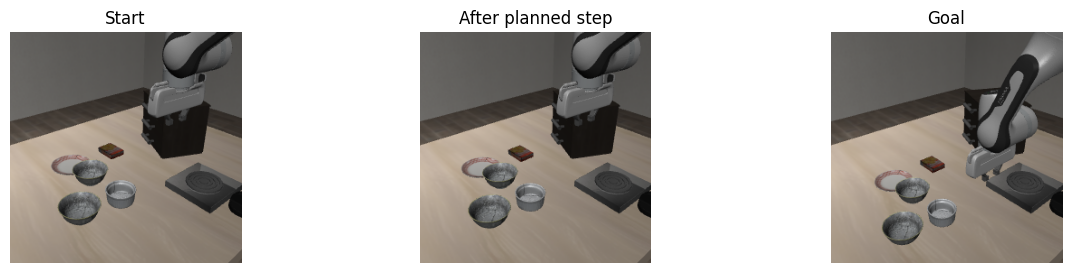

step=00 az=-0.0609 pred_drop=+0.003791 real_drop=+0.014349 reward=0.0 done=False


In [7]:
# Pass start and goal frames into V-JEPA2 world model and plan with CEM.
# Also log latent-energy diagnostics for the selected action.
def latent_energy(rep, goal_rep):
    return float(torch.mean(torch.abs(rep - goal_rep)).item())


def predict_next_rep_from_action(rep, pose_7d, action_7d):
    action_t = torch.tensor(action_7d, dtype=torch.float32, device=device)[None, None]
    pose_t = torch.tensor(pose_7d, dtype=torch.float32, device=device)[None, None]
    rep_t = rep[:, None]  # [B, T=1, N_tokens, D]
    next_rep = predictor(rep_t.flatten(1, 2), action_t, pose_t)[:, -tokens_per_frame:]
    if world_model.normalize_reps:
        next_rep = F.layer_norm(next_rep, (next_rep.size(-1),))
    return next_rep


def predict_rep_after_plan(rep, pose_7d, action_plan_7d):
    rep_curr = rep
    pose_curr = torch.tensor(pose_7d, dtype=torch.float32, device=device)[None, None]
    for h in range(action_plan_7d.shape[0]):
        action_t = torch.tensor(action_plan_7d[h], dtype=torch.float32, device=device)[None, None]
        rep_t = rep_curr[:, None]
        rep_next = predictor(rep_t.flatten(1, 2), action_t, pose_curr)[:, -tokens_per_frame:]
        if world_model.normalize_reps:
            rep_next = F.layer_norm(rep_next, (rep_next.size(-1),))
        pose_curr = compute_new_pose(pose_curr, action_t)
        rep_curr = rep_next
    return rep_curr


with torch.no_grad():
    z_n = world_model.encode(start_frame)
    z_goal = world_model.encode(goal_frame)
    energy_before = latent_energy(z_n, z_goal)
    s_n = torch.tensor(start_pose, dtype=torch.float32, device=device)[None, None]

    print("Starting MPC planning with energy diagnostics...")
    action_plan = world_model.infer_next_action(z_n, s_n, z_goal).detach().cpu().numpy()

# infer_next_action returns [rollout, 7]. If rollout=1, shape is [1, 7].
print("action_plan shape:", action_plan.shape)
planned_action = np.asarray(action_plan[0], dtype=np.float32).reshape(-1)
print("Planned first action (7D):", planned_action)
print("Planned horizon actions (7D each):")
print(action_plan)

with torch.no_grad():
    z_pred_after = predict_next_rep_from_action(z_n, start_pose, planned_action)
    energy_pred_after = latent_energy(z_pred_after, z_goal)
    predicted_drop = energy_before - energy_pred_after

    z_pred_after_horizon = predict_rep_after_plan(z_n, start_pose, action_plan)
    energy_pred_after_horizon = latent_energy(z_pred_after_horizon, z_goal)
    predicted_drop_horizon = energy_before - energy_pred_after_horizon

obs_after, reward, done, info = env.step(planned_action)
after_frame = env.get_image(obs_after)

with torch.no_grad():
    z_real_after = world_model.encode(after_frame)
    energy_real_after = latent_energy(z_real_after, z_goal)
    realized_drop = energy_before - energy_real_after

history_actions = [planned_action]
trajectory_frames = [start_frame, after_frame]
energy_debug = [
    {
        "step": 0,
        "energy_before": float(energy_before),
        "energy_pred_after": float(energy_pred_after),
        "predicted_drop": float(predicted_drop),
        "energy_pred_after_horizon": float(energy_pred_after_horizon),
        "predicted_drop_horizon": float(predicted_drop_horizon),
        "energy_real_after": float(energy_real_after),
        "realized_drop": float(realized_drop),
        "action": planned_action.astype(np.float32).tolist(),
        "action_plan": action_plan.astype(np.float32).tolist(),
        "reward": float(reward),
        "done": bool(done),
    }
]

plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
plt.imshow(start_frame)
plt.title("Start")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(after_frame)
plt.title("After planned step")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(goal_frame)
plt.title("Goal")
plt.axis("off")
plt.show()

print(
    f"step=00 az={planned_action[2]:+.4f} "
    f"pred_drop_1={predicted_drop:+.6f} pred_drop_H={predicted_drop_horizon:+.6f} "
    f"real_drop={realized_drop:+.6f} "
    f"reward={reward} done={done}"
)

In [8]:
# Optional: closed-loop replanning for a few steps.
# Also record frames and latent-energy diagnostics.
current_obs = obs_after
trajectory_fps = 8

closed_loop_steps = 10  # increase if you want a longer rollout
for t in range(closed_loop_steps):
    current_frame = env.get_image(current_obs)
    current_pose = env.get_pose_7d(current_obs)

    with torch.no_grad():
        z_n = world_model.encode(current_frame)
        energy_before = latent_energy(z_n, z_goal)
        s_n = torch.tensor(current_pose, dtype=torch.float32, device=device)[None, None]
        action_plan_t = world_model.infer_next_action(z_n, s_n, z_goal).detach().cpu().numpy()
        a = np.asarray(action_plan_t[0], dtype=np.float32).reshape(-1)

        z_pred_after = predict_next_rep_from_action(z_n, current_pose, a)
        energy_pred_after = latent_energy(z_pred_after, z_goal)
        predicted_drop = energy_before - energy_pred_after

        z_pred_after_horizon = predict_rep_after_plan(z_n, current_pose, action_plan_t)
        energy_pred_after_horizon = latent_energy(z_pred_after_horizon, z_goal)
        predicted_drop_horizon = energy_before - energy_pred_after_horizon

    current_obs, reward, done, info = env.step(a)
    history_actions.append(a)
    current_after_frame = env.get_image(current_obs)
    trajectory_frames.append(current_after_frame)

    with torch.no_grad():
        z_real_after = world_model.encode(current_after_frame)
        energy_real_after = latent_energy(z_real_after, z_goal)
        realized_drop = energy_before - energy_real_after

    energy_debug.append(
        {
            "step": int(t + 1),
            "energy_before": float(energy_before),
            "energy_pred_after": float(energy_pred_after),
            "predicted_drop": float(predicted_drop),
            "energy_pred_after_horizon": float(energy_pred_after_horizon),
            "predicted_drop_horizon": float(predicted_drop_horizon),
            "energy_real_after": float(energy_real_after),
            "realized_drop": float(realized_drop),
            "action": a.astype(np.float32).tolist(),
            "action_plan": action_plan_t.astype(np.float32).tolist(),
            "reward": float(reward),
            "done": bool(done),
        }
    )

    print(
        f"step={t+1:02d} az={a[2]:+.4f} "
        f"pred_drop_1={predicted_drop:+.6f} pred_drop_H={predicted_drop_horizon:+.6f} "
        f"real_drop={realized_drop:+.6f} reward={reward} done={done}"
    )

predicted_drops = np.array([d["predicted_drop"] for d in energy_debug], dtype=np.float32)
realized_drops = np.array([d["realized_drop"] for d in energy_debug], dtype=np.float32)

print("Collected", len(history_actions), "planned actions.")
print("Collected", len(trajectory_frames), "frames for video.")
print("Collected", len(energy_debug), "energy diagnostics entries.")
print("Current sim state length:", len(env.get_sim_state()))

[INFO    ][2026-03-11 16:34:59][utils.mpc_utils     ][cem                      ] new mean: tensor([-0.0594,  0.0277, -0.0520,  0.6085], device='cuda:1') tensor([0.0580, 0.0663, 0.0599, 0.1995], device='cuda:1')
[INFO    ][2026-03-11 16:35:03][utils.mpc_utils     ][cem                      ] new mean: tensor([-0.0727,  0.0678, -0.0715,  0.7288], device='cuda:1') tensor([0.0435, 0.0498, 0.0449, 0.0299], device='cuda:1')
[INFO    ][2026-03-11 16:35:08][utils.mpc_utils     ][cem                      ] new mean: tensor([-0.0746,  0.0739, -0.0745,  0.7468], device='cuda:1') tensor([0.0326, 0.0374, 0.0337, 0.0045], device='cuda:1')
[INFO    ][2026-03-11 16:35:13][utils.mpc_utils     ][cem                      ] new mean: tensor([-0.0749,  0.0748, -0.0749,  0.7495], device='cuda:1') tensor([0.0245, 0.0280, 0.0253, 0.0007], device='cuda:1')
[INFO    ][2026-03-11 16:35:18][utils.mpc_utils     ][cem                      ] new mean: tensor([-0.0750,  0.0750, -0.0750,  0.7499], device='cuda:1') ten

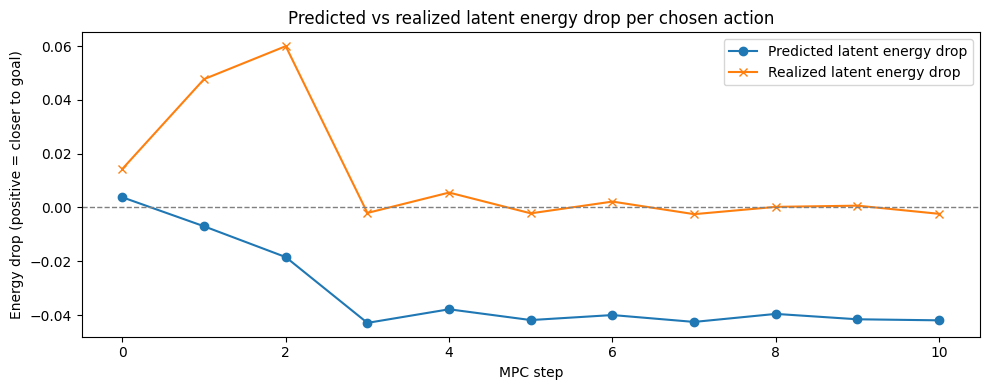

Saved trajectory video to: libero_planned_trajectory.mp4
Saved trajectory gif to:   libero_planned_trajectory.gif
Saved energy diagnostics:  libero_energy_diagnostics.json
Saved inferred actions:    libero_inferred_actions.npy
Saved energy plot:         libero_energy_drop_curve.png


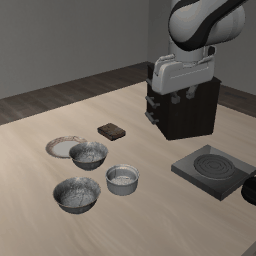

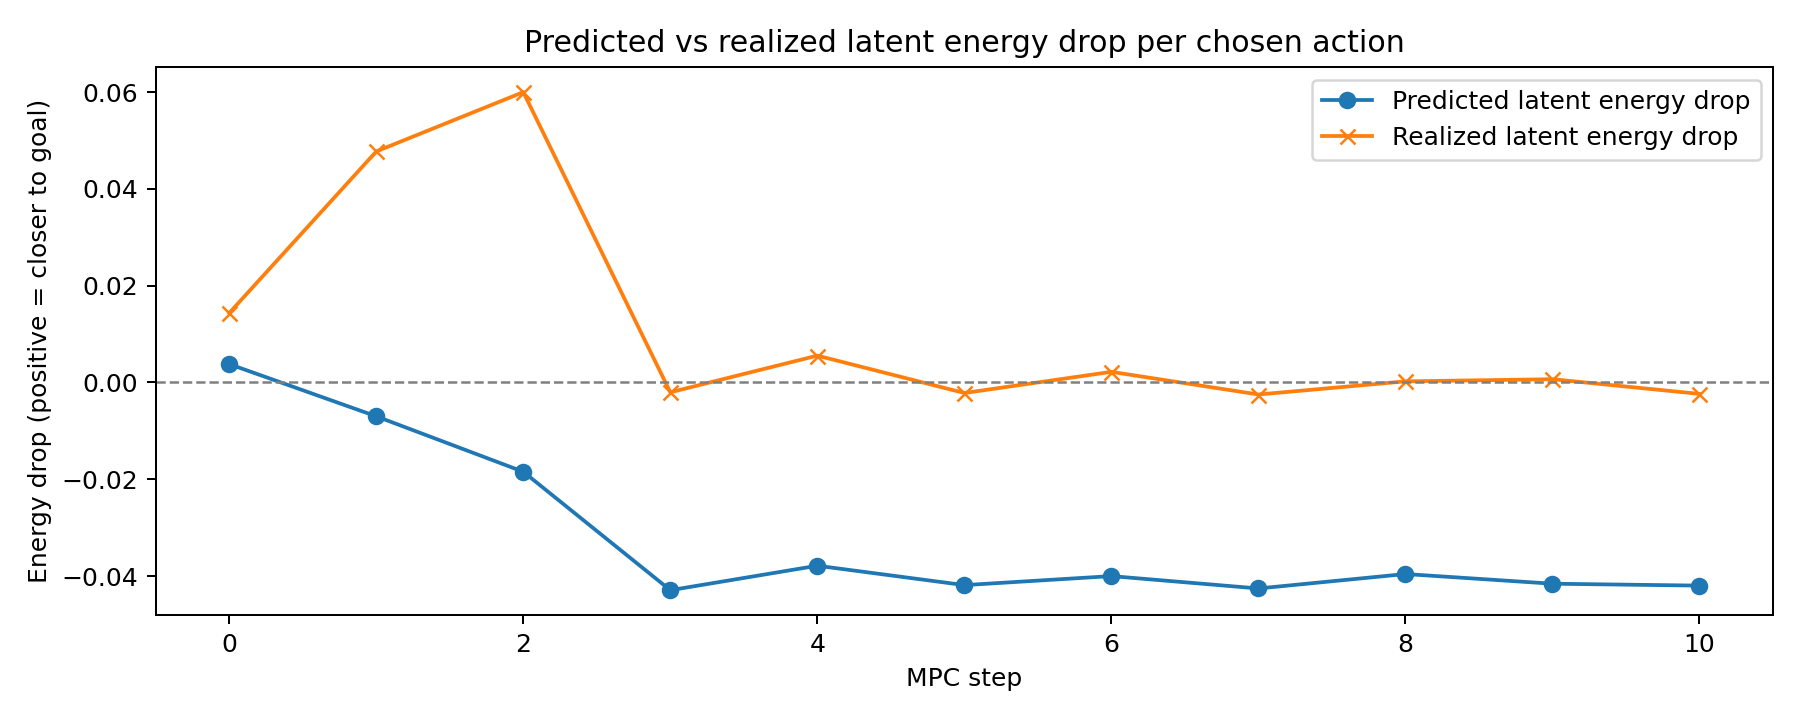

In [9]:
# Save and preview planned trajectory video + gif.
from IPython.display import HTML, Image, display
import imageio.v2 as imageio
import json

video_path = "libero_planned_trajectory.mp4"
gif_path = "libero_planned_trajectory.gif"
energy_json_path = "libero_energy_diagnostics.json"
actions_path = "libero_inferred_actions.npy"
energy_plot_path = str(Path(energy_json_path).with_name("libero_energy_curve.png"))

# MP4
writer = imageio.get_writer(video_path, fps=trajectory_fps)
for frame in trajectory_frames:
    writer.append_data(frame)
writer.close()

# GIF
# Note: duration is seconds per frame
gif_duration = 1.0 / trajectory_fps
imageio.mimsave(gif_path, trajectory_frames, format="GIF", duration=gif_duration, loop=0)

# Save action trajectory + diagnostics
np.save(actions_path, np.asarray(history_actions, dtype=np.float32))
with open(energy_json_path, "w", encoding="utf-8") as f:
    json.dump(energy_debug, f, indent=2)

# Plot realized energy curve + one-step and horizon-end predictions
n_steps = len(energy_debug)
x_real = np.arange(n_steps + 1, dtype=np.float32)
y_real = np.array(
    [energy_debug[0]["energy_before"]] + [d["energy_real_after"] for d in energy_debug],
    dtype=np.float32,
)
x_pred = np.arange(1, n_steps + 1, dtype=np.float32)
y_pred_1 = np.array([d["energy_pred_after"] for d in energy_debug], dtype=np.float32)
y_pred_h = np.array(
    [d.get("energy_pred_after_horizon", d["energy_pred_after"]) for d in energy_debug],
    dtype=np.float32,
)

plt.figure(figsize=(10, 4))
plt.plot(x_real, y_real, marker="o", linewidth=2.0, label="Realized latent energy")
plt.plot(
    x_pred,
    y_pred_1,
    linestyle=":",
    marker="x",
    linewidth=1.5,
    label="WM predicted energy after first action",
)
plt.plot(
    x_pred,
    y_pred_h,
    linestyle="--",
    marker="s",
    markersize=4,
    linewidth=1.2,
    label=f"WM predicted energy after horizon={world_model.mpc_args['rollout']}",
)
for i in range(n_steps):
    x = float(i + 1)
    plt.plot([x, x], [y_real[i + 1], y_pred_1[i]], linestyle=":", linewidth=1.0, color="gray")

plt.xlabel("State index (after each MPC action)")
plt.ylabel("Latent energy")
plt.title("Realized energy with first-action and horizon-end WM projections")
plt.legend()
plt.tight_layout()
plt.savefig(energy_plot_path, dpi=180)
plt.show()

print(f"Saved trajectory video to: {video_path}")
print(f"Saved trajectory gif to:   {gif_path}")
print(f"Saved energy diagnostics:  {energy_json_path}")
print(f"Saved inferred actions:    {actions_path}")
print(f"Saved energy plot:         {energy_plot_path}")

display(HTML(f"""
<video width="720" controls>
    <source src="{video_path}" type="video/mp4">
</video>
"""))
display(Image(filename=gif_path))
display(Image(filename=energy_plot_path))

In [ ]:
# Cleanup
env.close()